In [108]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cudaq
import sys
import os
import shutil
import faulthandler
from scipy.linalg import expm
from math import sqrt
from tqdm import tqdm
import torch
from typing import List, Tuple
sys.path.append(os.path.abspath(".."))
from Utils.qaoaCUDAQ import po_normalize, ret_cov_to_QUBO, qubo_to_ising, process_ansatz_values, kernel_flipped, all_state_to_return, find_budget

In [212]:
e = 0
N_ASSETS = 3
TARGET_QUBIT_IN = 2
q = 0
lamb = 0

device = torch.device("cuda")
DUPLICATE_ASSET = False
min_P, max_P = 108, 216

In [213]:
data_cov_pd = pd.read_csv("../dataset/top_50_us_stocks_data_20250526_011226_covariance.csv")
data_ret_p_pd = pd.read_csv("../dataset/top_50_us_stocks_returns_price.csv")

data_ret_p_pd = data_ret_p_pd[(data_ret_p_pd["Price"] > min_P) & (data_ret_p_pd["Price"] < max_P)]
data_cov_pd = data_cov_pd.loc[data_cov_pd["Ticker"].isin(data_ret_p_pd["Ticker"])].reset_index(drop=True)
data_cov_pd = data_cov_pd[["Ticker"] + data_cov_pd["Ticker"].tolist()]

In [214]:
np.random.seed(911 + 991 * e + 997 * N_ASSETS)
state = np.random.get_state()
# asset_idx = np.random.choice(data_cov_pd.shape[0], max(TARGET_ASSET), replace=False)
asset_idx = np.random.choice(data_cov_pd.shape[0], N_ASSETS, replace=DUPLICATE_ASSET)
# print(asset_idx)
# asset_idx = np.array([0, 18, 27, 32, 41])
# data_cov = data_cov_pd.drop("Ticker", axis=1)
data_cov = data_cov_pd.drop("Ticker", axis=1).to_numpy()[asset_idx, :][:, asset_idx]
stock_names = data_ret_p_pd["Company_Name"].to_numpy()[asset_idx]
# print("Selected Stocks: ", stock_names)
data_ret_p = data_ret_p_pd.drop("Ticker", axis=1)
# print(data_ret_p.index[asset_idx].to_numpy())
asset_idx_raw = data_ret_p.index[asset_idx].to_numpy()
data_ret_p = data_ret_p.drop("Company_Name", axis=1).to_numpy()[asset_idx, :]

data_ret = data_ret_p[:, 0]
data_p = data_ret_p[:, 1]
print("Selected Stocks: ", stock_names)
print("Selected Stocks Price: ", data_p)
print("Selected Stocks Return: ", data_ret)

Selected Stocks:  ['Philip Morris International Inc.' 'Abbott Laboratories' 'Broadcom Inc.']
Selected Stocks Price:  [158.72999573 132.0383606  167.42999268]
Selected Stocks Return:  [0.00060737 0.00060593 0.00142008]


In [215]:
np.random.set_state(state)
weighted = np.random.uniform(0, 1)
B_mi, B_ma = find_budget(TARGET_QUBIT_IN * N_ASSETS, data_p, min_P, max_P, min_mix_mode=True)
B = B_mi * weighted + B_ma * (1 - weighted)

P = data_p[:N_ASSETS]
ret = data_ret[:N_ASSETS]
cov = data_cov[:N_ASSETS, :N_ASSETS]
P_bb, ret_bb, cov_bb, n_qubit, n_max, C = po_normalize(B, P, ret, cov)
TARGET_QUBIT = n_qubit

# QUBOs of MAX PROBLEM
QU = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, lamb, q)
QU_lamb = ret_cov_to_QUBO(np.zeros_like(ret_bb), np.zeros_like(cov_bb), P_bb, lamb, 0.0)
QU_eval = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, 0.0, q)
QU_return = ret_cov_to_QUBO(ret_bb, np.zeros_like(cov_bb), np.zeros_like(P_bb), 0.0, 0.0)
QU_risk = ret_cov_to_QUBO(np.zeros_like(ret_bb), cov_bb, np.zeros_like(P_bb), 0.0, q)

# Hamiltonians of MIN PROBLEM
H_ansatz = -qubo_to_ising(QU, lamb).canonicalize()
H_lamb = -qubo_to_ising(QU_lamb, lamb).canonicalize()
H_eval = -qubo_to_ising(QU_eval, 0.0).canonicalize()
H_return = -qubo_to_ising(QU_return, 0.0).canonicalize()
H_risk = -qubo_to_ising(QU_risk, 0.0).canonicalize()

idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use = process_ansatz_values(H_ansatz)

In [216]:
n_b = 1<<TARGET_QUBIT
H = H_ansatz.to_matrix()
print("Is Hermitian:", (H == np.conj(H).T).all())
eigvals, eigvecs = np.linalg.eigh(H)

eigvals = np.random.rand(n_b) * 3
eigvals = np.sort(eigvals)
# eigvals = eigvals - eigvals[0]
# eigvals[1:] += 1

H = eigvecs @ np.diag(eigvals) @ eigvecs.T
# print("Modified H:\n", H)

for i in range(len(eigvals)):
    print(f"Eigenvalue {i}: {eigvals[i]}")
    print(f"Eigenvector {i}:\n{eigvecs[:, i]}\n")

ground_state = eigvecs[:, 0]
print("Ground state:\n", ground_state)

# print(np.linalg.eigh(H))
# print(np.linalg.eig(H))

# b = np.random.rand(n_b)
b = np.ones(n_b)
b = b / np.linalg.norm(b)
print("Vector b:\n", b)

spectral_gap = eigvals[1] - eigvals[0]
spectral_radius = max(abs(eigvals))
print("\nSpectral gap:", spectral_gap)
print("Spectral radius:", spectral_radius)

ss = spectral_gap / (12 * spectral_radius**3)
F0 = abs(b @ ground_state)**2
print("F0:", F0)
q = 1 - ss * F0 * spectral_gap
print("q:", q)
print("Recommended step size (s):", ss)
assert spectral_radius > 1

Is Hermitian: True
Eigenvalue 0: 0.026456695199172486
Eigenvector 0:
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 1.+0.j]

Eigenvalue 1: 0.0762567911048947
Eigenvector 1:
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j


In [217]:
def commutator(A, B):
    return A @ B - B @ A

In [218]:
assert False

AssertionError: 

In [ ]:
# tau = 200
# tau = 0.2
N = 60000
tau = ss * N
# N = 100

print("tau:", tau)


# e^(-tau H)
exp_H = expm(-tau * H)
print("Exponential of -tau * H:\n", exp_H)
result
result = exp_H @ b
result = result / np.linalg.norm(result)
print("Fidelity with ground state:", abs(result @ ground_state)**2)

print("Result of normed exp(-tau * H) @ b:", result)
# print("Result of normed exp(-tau * H) @ b:", np.round(result))

tau: 9.540502251801792
Exponential of -tau * H:
 [[9.06598106e-11+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j ...
  0.00000000e+00+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j]
 [0.00000000e+00+0.j 1.59936420e-07+0.j 0.00000000e+00+0.j ...
  0.00000000e+00+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j]
 [0.00000000e+00+0.j 0.00000000e+00+0.j 7.62544591e-04+0.j ...
  0.00000000e+00+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j]
 ...
 [0.00000000e+00+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j ...
  2.67437748e-11+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j]
 [0.00000000e+00+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j ...
  0.00000000e+00+0.j 1.40157521e-12+0.j 0.00000000e+00+0.j]
 [0.00000000e+00+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j ...
  0.00000000e+00+0.j 0.00000000e+00+0.j 5.12416601e-13+0.j]]
Fidelity with ground state: 0.577363176706021
Result of normed exp(-tau * H) @ b: [8.86665250e-11+0.j 1.56419989e-07+0.j 7.45778957e-04+0.j
 1.15929260e-01+0.j 7.87436940e-08+0.j 4.36132701e-05+0.j
 1.083943

In [ ]:
s = tau / N

s = 1
N = 3

bb = b.copy()
bb_t = torch.tensor(bb, device=device, dtype=torch.complex64)
H_t = torch.tensor(H, device=device, dtype=torch.complex64)
for i in tqdm(range(N)):
    densi = torch.outer(bb_t, bb_t)
    Q = torch.matrix_exp(s * (densi @ H_t - H_t @ densi))
    bb_t = Q @ bb_t
bb = bb_t.cpu().numpy()
result = bb
print("Fidelity with ground state:", abs(result @ ground_state)**2)
print("Result:", result)
print("Norm:", np.linalg.norm(result))
# print(np.round(result))
print(np.abs(result)**2)

100%|██████████| 3/3 [00:00<00:00, 981.66it/s]

Fidelity with ground state: 0.1343120850545496
Result: [-3.09395976e-02+0.j  2.21435912e-03+0.j  5.23474365e-02+0.j
  2.43075237e-01+0.j  3.34087154e-03+0.j  1.14450958e-02+0.j
  2.39260525e-01+0.j  8.99713188e-02+0.j  1.03097735e-02+0.j
  1.87714681e-01+0.j  1.42472312e-01+0.j -2.75296159e-04+0.j
  1.63573921e-01+0.j  1.83067307e-01+0.j  3.13857943e-03+0.j
  4.65569552e-03+0.j  1.44855981e-03+0.j  6.24318942e-02+0.j
  2.83080101e-01+0.j  3.51213589e-02+0.j  1.65514648e-02+0.j
  2.71166861e-01+0.j  7.70799741e-02+0.j  2.42385082e-04+0.j
  1.92820147e-01+0.j  1.33723885e-01+0.j -3.54642514e-04+0.j
  4.16201632e-03+0.j  1.48878813e-01+0.j  2.72269361e-03+0.j
  4.73107863e-03+0.j -4.67133746e-02+0.j  7.82157555e-02+0.j
  3.32151383e-01+0.j  2.85252221e-02+0.j  2.78869644e-03+0.j
  3.66486132e-01+0.j  7.49703050e-02+0.j  1.08213699e-03+0.j
 -1.35800391e-02+0.j  9.18326676e-02+0.j -4.62807016e-04+0.j
  2.33577774e-03+0.j -6.89879358e-02+0.j  4.29316424e-05+0.j
  4.70729079e-03+0.j -4.775744

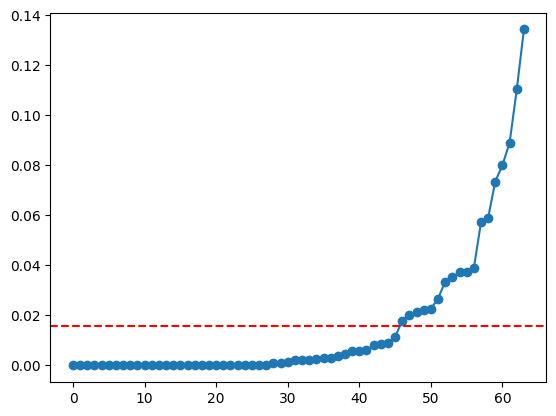

In [ ]:
plt.plot(sorted(abs(result)**2), marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')

In [ ]:
s = tau / N

s = 1
N = 5

bb = b.copy()
# for i in range(N):
#     densi = np.outer(bb, bb)
#     E1 = expm(-1j*sqrt(s)*H)
#     E2 = expm(1j*sqrt(s)*densi)
#     E3 = expm(1j*sqrt(s)*H)
#     bb = np.exp(-1j*sqrt(s)) * E3 @ E2 @ E1 @ bb
#     print(f"iter {i+1}")
#     F_k = abs(bb @ ground_state)**2
#     print(f"F_{i+1}:", F_k)
#     print("bb:", bb)
#     lower_bound = 1 - q**(i)
#     print(f"Lower bound for F_{i+1}:", lower_bound)
#     print()
bb_t = torch.tensor(bb, device=device, dtype=torch.complex64)
H_t = torch.tensor(H, device=device, dtype=torch.complex64)
ground_state_t = torch.tensor(ground_state, device=device, dtype=torch.complex64)
E1 = torch.matrix_exp(-1j*sqrt(s)*H_t)
E3 = torch.matrix_exp(1j*sqrt(s)*H_t)
E1_dagger = torch.adjoint(E1)
for i in tqdm(range(N)):
    densi = torch.outer(bb_t, bb_t)
    E2 = torch.matrix_exp(1j*sqrt(s)*densi)
    E2_dagger = torch.adjoint(E2)
    E321 = E3 @ E2 @ E1
    E321_dagger = torch.adjoint(E321)
    print(torch.trace(E2_dagger @ E2))
    eigvalss, eigvecss = torch.linalg.eig(E321)
    print("Eigenvalues of E321:", torch.sort(torch.abs(eigvalss)))
    bbb = bb_t.clone()
    bb_t = E321 @ bb_t
    if (i+1) % 1 == 0:
        F_k = abs(bb_t @ ground_state_t)**2
        print(f"iter {i+1}")
        print("norm of bb_t:", torch.norm(bb_t).item())
        print(f"F_{i+1}:", F_k)
        lower_bound = 1 - q**(i+1)
        print(f"Lower bound for F_{i+1}:", lower_bound)
        print()
bb = bb_t.cpu().numpy()

print("Fidelity with ground state:", abs(bb @ ground_state)**2)
print("Result of DB-QITE:", bb)
print("Abs of DB-QITE result:", np.abs(bb) * np.sign(bb.real))
print("Norm of DB-QITE result:", np.linalg.norm(bb))

100%|██████████| 5/5 [00:00<00:00, 223.39it/s]

tensor(64.0000+7.9007e-10j, device='cuda:0')
Eigenvalues of E321: torch.return_types.sort(
values=tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0'),
indices=tensor([ 2,  3,  6, 37, 48,  5, 41, 24, 11, 26, 51, 59, 20, 45,  9, 30, 34, 35,
        39, 47, 50, 55, 61, 27, 53,  1, 29, 40,  7, 19, 33,  0, 22, 32, 38, 44,
        49, 60, 63, 12, 52, 56, 58, 62, 42, 57, 36, 46, 15, 21, 28, 25, 23, 43,
        54,  8, 17, 31, 16,  4, 13, 18, 10, 14], device='cu

In [ ]:
print(torch.trace(E1 @ E3))
print(np.exp(-1j*sqrt(s)))

tensor(64.0000-2.3571e-08j, device='cuda:0')
(0.5403023058681398-0.8414709848078965j)


In [ ]:
print(s)

1


In [ ]:
# print(densi)
densi = torch.outer(bbb, bbb)
dd = torch.matrix_exp(1j*10*densi)
dd_dagger = torch.adjoint(dd)
print(torch.trace(dd_dagger @ dd))
print(torch.diag(dd_dagger @ dd))

tensor(81.3487+6.9221e-09j, device='cuda:0')
tensor([1.3440+4.0547e-10j, 1.2384+1.7843e-09j, 1.0677-1.7914e-10j,
        1.1757-3.9362e-10j, 1.2541+4.1151e-10j, 1.0826-2.7424e-10j,
        1.1733-1.2815e-10j, 1.0833-1.5965e-10j, 1.0849-3.4775e-10j,
        1.1408-2.5897e-10j, 1.1131-2.4337e-10j, 1.1529-9.5170e-10j,
        1.1259+3.8308e-10j, 1.1380+8.6845e-11j, 1.1109+1.0123e-10j,
        1.2734+4.9841e-10j, 1.2264-3.0131e-10j, 1.0709-1.1435e-10j,
        1.2012-9.4106e-10j, 1.0658-1.1288e-09j, 1.0750-2.7854e-10j,
        1.1936+6.7614e-10j, 1.0770+3.4189e-10j, 1.2021-2.2893e-10j,
        1.1440+4.7221e-10j, 1.1078-3.0026e-10j, 1.1565-4.1342e-10j,
        1.2823+6.1021e-10j, 1.1169-2.5048e-10j, 1.1136-3.8656e-11j,
        1.2758+1.0608e-09j, 1.3984+8.8874e-11j, 1.0775-4.0280e-10j,
        1.2327-3.3542e-10j, 1.0670-4.3340e-10j, 1.2466+1.2020e-09j,
        1.2550-1.2218e-09j, 1.0760+4.8917e-10j, 1.2200-4.3626e-10j,
        1.3019-4.4862e-10j, 1.0842-1.7185e-10j, 1.1691+2.5013e-10j,
   

In [ ]:
eig_valss, eig_vecss = torch.linalg.eig(dd)
print(abs(eig_valss))
print(eig_vecss[:, 1])

tensor([1.4862, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0')
tensor([ 0.7265+0.0000j, -0.0513-0.0435j,  0.0216-0.0304j,  0.0481-0.0808j,
        -0.0339-0.0092j, -0.0188-0.0389j,  0.0419-0.0385j,  0.0243-0.0433j,
        -0.0060-0.0357j,  0.0382-0.0818j,  0.0368-0.1044j,  0.0086+0.0227j,
         0.0335-0.0848j,  0.0296-0.0600j, -0.0547-0.0709j, -0.0307-0.0451j,
        -0.1599+0.0037j,  0.0110-0.0438j,  0.0605-0.0945j,  0.0064-0.0268j,
        -0.0081-0.0370j,  

In [ ]:
print(bbb)

tensor([0.0458-0.0506j, 0.0562-0.0207j, 0.0415+0.0263j, 0.0523+0.0646j,
        0.0574-0.0222j, 0.0428+0.0058j, 0.0520+0.0641j, 0.0431+0.0374j,
        0.0430+0.0048j, 0.0488+0.0565j, 0.0461+0.0488j, 0.0490-0.0106j,
        0.0473+0.0526j, 0.0485+0.0558j, 0.0453-0.0028j, 0.0584-0.0246j,
        0.0552-0.0195j, 0.0419+0.0296j, 0.0548+0.0698j, 0.0413+0.0195j,
        0.0421+0.0095j, 0.0540+0.0683j, 0.0425+0.0340j, 0.0532-0.0169j,
        0.0491+0.0573j, 0.0455+0.0471j, 0.0493-0.0111j, 0.0579-0.0270j,
        0.0465+0.0499j, 0.0455-0.0034j, 0.0584-0.0250j, 0.0438-0.0597j,
        0.0425+0.0343j, 0.0579+0.0756j, 0.0414+0.0163j, 0.0568-0.0215j,
        0.0601+0.0793j, 0.0424+0.0334j, 0.0547-0.0188j, 0.0498-0.0401j,
        0.0432+0.0379j, 0.0504-0.0129j, 0.0566-0.0291j, 0.0431-0.0718j,
        0.0482-0.0092j, 0.0584-0.0257j, 0.0438-0.0603j, 0.0516-0.1074j,
        0.0557+0.0717j, 0.0427+0.0062j, 0.0573-0.0222j, 0.0440-0.0585j,
        0.0416+0.0274j, 0.0553-0.0195j, 0.0483-0.0434j, 0.0456-0

In [284]:
k = 2
U = [None for _ in range(k+1)]
def conj(l):
    ll = [(a, b, -c) for (a, b, c) in l[::-1]]
    return ll

def dfs(n, i):
    if i == 0:
        return [("U", 0, 0)]
    if U[i] is not None:
        return U[i]
    U[i] = dfs(n, i-1) + [("H", i-1, -1)] + conj(dfs(n, i-1)) + [("D", i-1, 1)] + dfs(n, i-1) + [("H", i-1, 1)]
    return U[i]

In [285]:
dfs(k, k)
for i in range(k+1):
    print(f"U_{i}:", U[i])
# a = [('H', 0, 1), ('D', 0, -1)]
# print(conj(a))
type_l, tim_l, abs_l = zip(*U[k])
type_l = [0 if t == "H" else 1 if t == "D" else 2 for t in type_l]
tim_l = np.array(tim_l)
abs_l = np.array(abs_l)
type_l = np.array(type_l)

print("tim_l:", tim_l)
print("abs_l:", abs_l)
print("type_l:", type_l)

U_0: None
U_1: [('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1)]
U_2: [('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1), ('H', 1, -1), ('H', 0, -1), ('U', 0, 0), ('D', 0, -1), ('U', 0, 0), ('H', 0, 1), ('U', 0, 0), ('D', 1, 1), ('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1), ('H', 1, 1)]
tim_l: [0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1]
abs_l: [ 0 -1  0  1  0  1 -1 -1  0 -1  0  1  0  1  0 -1  0  1  0  1  1]
type_l: [2 0 2 1 2 0 0 0 2 1 2 0 2 1 2 0 2 1 2 0 0]


In [300]:
@cudaq.kernel
def kernel_DB_QITE(step_size: List[float], qubit_count: int, idx_1: List[int], coeff_1: List[float], idx_2_a: List[int], idx_2_b: List[int], coeff_2: List[float], type_l: List[int], tim_l: List[int], abs_l: List[float]):
    qreg = cudaq.qvector(qubit_count)
    # h(qreg)

    for i in range(len(type_l)):
        # H
        if type_l[i] == 0:
            for j in range(len(idx_1)):
                rz(2 * abs_l[i] * coeff_1[j] * step_size[tim_l[i]], qreg[idx_1[j]])
            for j in range(len(idx_2_a)):
                x.ctrl(qreg[idx_2_a[j]], qreg[idx_2_b[j]])
                rz(2  * abs_l[i] * coeff_2[j] * step_size[tim_l[i]], qreg[idx_2_b[j]])
                x.ctrl(qreg[idx_2_a[j]], qreg[idx_2_b[j]])
        
        # D
        elif type_l[i] == 1:
            # h(qreg)
            # rz(-1 * abs_l[i] * step_size[tim_l[i]], qreg[qubit_count-1])
            # x.ctrl(qreg[0:qubit_count-1], qreg[qubit_count-1])
            # rz(-1 * abs_l[i] * step_size[tim_l[i]], qreg[qubit_count-1])
            # x.ctrl(qreg[0:qubit_count-1], qreg[qubit_count-1])
            # rz(2 * abs_l[i] * step_size[tim_l[i]], qreg[qubit_count-1])
            # h(qreg)

            ### I'M SORRY DEAR, BUT THIS IS NOT e^(i|u><u|) YOU'RE LOOKING FOR
            # h(qreg)
            x(qreg)
            rz.ctrl(2 * abs_l[i] * step_size[tim_l[i]], qreg[0:qubit_count-1], qreg[qubit_count-1])
            x(qreg)
            # h(qreg)

        # U
        elif type_l[i] == 2:
            h(qreg)

In [301]:
print(cudaq.draw(kernel_DB_QITE, [1.0]*k, TARGET_QUBIT, idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use, type_l, tim_l, abs_l))

     ╭───╮╭────────────────╮╭───╮╭───╮         ╭───╮╭───╮╭───────────────╮»
q0 : ┤ h ├┤ rz(-0.0002034) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(0.0002034) ├»
     ├───┤├────────────────┤├───┤├───┤    │    ├───┤├───┤├───────────────┤»
q1 : ┤ h ├┤ rz(-0.0004068) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(0.0004068) ├»
     ├───┤├────────────────┤├───┤├───┤    │    ├───┤├───┤├───────────────┤»
q2 : ┤ h ├┤ rz(-0.0001688) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(0.0001688) ├»
     ├───┤├────────────────┤├───┤├───┤    │    ├───┤├───┤├───────────────┤»
q3 : ┤ h ├┤ rz(-0.0003376) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(0.0003376) ├»
     ├───┤├────────────────┤├───┤├───┤    │    ├───┤├───┤├───────────────┤»
q4 : ┤ h ├┤ rz(-0.0005017) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(0.0005017) ├»
     ├───┤├───────────────┬╯├───┤├───┤╭───┴───╮├───┤├───┤├──────────────┬╯»
q5 : ┤ h ├┤ rz(-0.001003) ├─┤ h ├┤ x ├┤ rz(2) ├┤ x ├┤ h ├┤ rz(0.001003) ├─»
     ╰───╯╰───────────────╯ ╰───╯╰───╯╰───────╯╰───╯╰───╯╰──────────────╯ »

###########

In [302]:
result = cudaq.get_state(kernel_DB_QITE, [1]*k, TARGET_QUBIT, idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use, type_l, tim_l, abs_l)
result_r = cudaq.get_state(kernel_flipped, result, TARGET_QUBIT)

In [303]:
# print(np.array(result_r))
uniform_state = np.ones_like(result) / np.sqrt(len(result))
print("Fidelity with ground state:", abs(uniform_state @ ground_state)**2)
print("Fidelity of result with ground state:", abs(result_r @ ground_state)**2)
# print("Result of DB-QITE:", np.array(result_r))

Fidelity with ground state: 0.015625
Fidelity of result with ground state: 0.015553970280967831


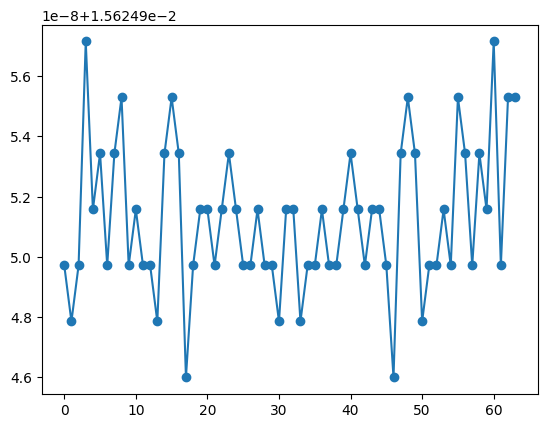

In [298]:
plt.plot(np.abs(result_r)**2, marker='o')

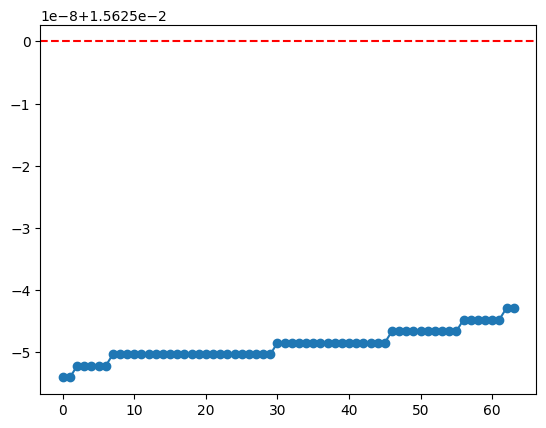

In [299]:
plt.plot(sorted(abs(np.array(result_r))**2), marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')

In [292]:
idx_gt = np.argmax(np.abs(ground_state))
idx_gt_bin = bin(idx_gt)[2:].zfill(TARGET_QUBIT)

idx_res = np.argmax(np.abs(result_r))
idx_res_min = np.argmin(np.abs(result_r))
idx_res_bin = bin(idx_res)[2:].zfill(TARGET_QUBIT)
idx_res_min_bin = bin(idx_res_min)[2:].zfill(TARGET_QUBIT)

print(f"Ground state significant indices : {idx_gt} ({idx_gt_bin})")
print(f"DB-QITE result significant indices : {idx_res} ({idx_res_bin})")
print(f"DB-QITE result minimal indices : {idx_res_min} ({idx_res_min_bin})")

Ground state significant indices : 63 (111111)
DB-QITE result significant indices : 0 (000000)
DB-QITE result minimal indices : 1 (000001)


In [293]:
print(np.array(result_r)[idx_res])
print(ground_state[idx_gt])
print(np.array(result_r) @ ground_state)

(-0.4161462+0.909296j)
(1+0j)
0j
